# SVM Model with NLP Data Augmentation
This notebook replicates the 5 Semantics-Preserving Data Augmentation techniques from the paper (Synonym Replacement, Phrase Insertion, Simplification, Random Swap, Deletion) and applies them to the SVM Baseline.

Our goal is to see if NLP Augmentation yields better F1-scores for minority classes compared to distance-based SMOTE or simple Class Weights.

In [1]:
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Import our custom augmentation library
from augmentation import RequirementAugmenter


## 1. Load Data

In [2]:
data_dir = '../data/processed'
train_df = pd.read_csv(f"{data_dir}/train.csv")
test_df = pd.read_csv(f"{data_dir}/test.csv")

# Filter NFRs for Multi-class training
train_nfr_df = train_df[train_df['label_binary'] == 'NFR'].copy().reset_index(drop=True)
test_nfr_df = test_df[test_df['label_binary'] == 'NFR'].copy().reset_index(drop=True)

print("Original Train NFR Distribution:", dict(Counter(train_nfr_df['sub_NFR'])))


Original Train NFR Distribution: {'A': 62, 'FT': 20, 'SE': 152, 'O': 115, 'US': 105, 'LF': 73, 'PE': 112, 'SC': 28, 'MN': 42, 'L': 34, 'PO': 15}


## 2. Apply NLP Data Augmentation
We balance the minority classes by generating synthetic sentences using our 5 strategies until all classes reach the size of the majority class.

In [3]:
aug = RequirementAugmenter()

class_counts = Counter(train_nfr_df['sub_NFR'])
max_count = max(class_counts.values())
print(f"Target count per class: {max_count}")

augmented_rows = []

start_aug = time.time()
for label, count in class_counts.items():
    if count < max_count:
        num_to_generate = max_count - count
        # Get all existing texts for this label
        existing_texts = train_nfr_df[train_nfr_df['sub_NFR'] == label]['text'].tolist()
        
        for _ in range(num_to_generate):
            base_text = random.choice(existing_texts)
            # Generate augmented version
            try:
                new_text = aug.augment(base_text, strategy='random')
            except Exception:
                new_text = base_text # Fallback if augmentation fails
            
            augmented_rows.append({'text': new_text, 'raw_label': 'AUG', 'label_binary': 'NFR', 'sub_NFR': label, 'source': 'AUG'})

aug_time = time.time() - start_aug
print(f"Data Augmentation Time: {aug_time:.2f} seconds")

aug_df = pd.DataFrame(augmented_rows)
train_nfr_balanced = pd.concat([train_nfr_df, aug_df], ignore_index=True)

print("\nAfter NLP Augmentation:", dict(Counter(train_nfr_balanced['sub_NFR'])))


[nltk_data] Downloading package wordnet to C:\Users\ThinkPad
[nltk_data]     X1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\ThinkPad
[nltk_data]     X1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ThinkPad X1\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to C:\Users\ThinkPad
[nltk_data]     X1\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Target count per class: 152
Data Augmentation Time: 2.38 seconds

After NLP Augmentation: {'A': 152, 'FT': 152, 'SE': 152, 'O': 152, 'US': 152, 'LF': 152, 'PE': 152, 'SC': 152, 'MN': 152, 'L': 152, 'PO': 152}


## 3. Feature Engineering (TF-IDF)
We fit TF-IDF on the newly augmented balanced dataset.

In [4]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train_aug_tfidf = vectorizer.fit_transform(train_nfr_balanced['text'])
y_train_aug = train_nfr_balanced['sub_NFR'].values

X_test_nfr_tfidf = vectorizer.transform(test_nfr_df['text'])
y_test_nfr = test_nfr_df['sub_NFR'].values

print(f"TF-IDF Matrix shape (Augmented Train): {X_train_aug_tfidf.shape}")


TF-IDF Matrix shape (Augmented Train): (1672, 5000)


## 4. Model Training & Evaluation

In [5]:
# Train Multi-class SVM
svm_multi_aug = SVC(kernel='linear', decision_function_shape='ovr', class_weight='balanced', random_state=42)

start_time = time.time()
svm_multi_aug.fit(X_train_aug_tfidf, y_train_aug)
train_time_multi = time.time() - start_time

print(f"Multi-class Model (Augmented Data) Training Time: {train_time_multi:.4f} seconds")


Multi-class Model (Augmented Data) Training Time: 0.3814 seconds


Accuracy (Sub-NFR Multi-class - Augmented): 0.7037

Classification Report (Sub-NFR - Augmented):
              precision    recall  f1-score   support

           A       0.36      0.57      0.44         7
          FT       0.50      0.25      0.33         8
           L       0.67      0.67      0.67         6
          LF       0.75      0.77      0.76        31
          MN       0.90      0.56      0.69        16
           O       0.85      0.77      0.81        22
          PE       0.76      0.76      0.76        17
          PO       0.67      0.40      0.50         5
          SC       0.50      0.50      0.50         8
          SE       0.70      0.95      0.81        20
          US       0.67      0.73      0.70        22

    accuracy                           0.70       162
   macro avg       0.67      0.63      0.63       162
weighted avg       0.72      0.70      0.70       162



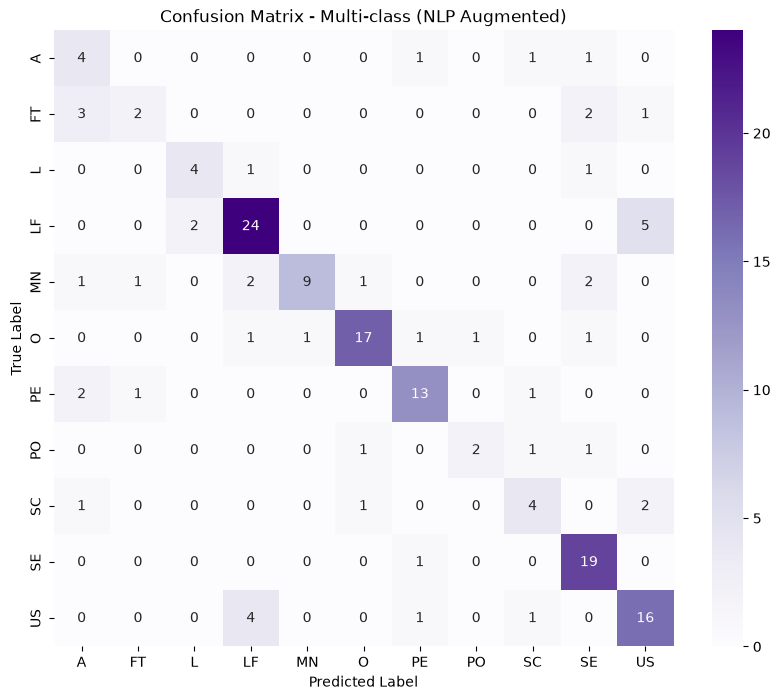

In [6]:
# Evaluate on Test NFRs
y_pred_nfr_aug = svm_multi_aug.predict(X_test_nfr_tfidf)

acc_multi = accuracy_score(y_test_nfr, y_pred_nfr_aug)
print(f"Accuracy (Sub-NFR Multi-class - Augmented): {acc_multi:.4f}")
print("\nClassification Report (Sub-NFR - Augmented):")
print(classification_report(y_test_nfr, y_pred_nfr_aug))

# Confusion Matrix
labels = np.unique(y_test_nfr)
cm_multi = confusion_matrix(y_test_nfr, y_pred_nfr_aug, labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Multi-class (NLP Augmented)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
